# Assignment 4

1. Log transform, c = 1.
2. Power law / gamma transform, c = 1 and gamma from user.
3. Contrast stretching using input and output ranges from user.


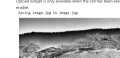

In [1]:
import cv2
import numpy as np

img = cv2.imread('images/sample_image.jpg')
B = img[:, :, 0].astype(np.float64)
G = img[:, :, 1].astype(np.float64)
R = img[:, :, 2].astype(np.float64)

gray = ((R + G + B) / 3).astype(np.uint8)
r = gray.astype(np.float64) / 255.0


## 1. Log Transform


In [2]:
c = 1
log_image = c * np.log(1 + r)
log_image = (log_image / log_image.max() * 255).astype(np.uint8)
cv2.imwrite('outputs/assignment4/log_transform.jpg', log_image)


## 2. Gamma Transform


Enter gamma value: 0.5
Gamma used: 0.5


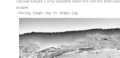

In [3]:
gamma = float(input('Enter gamma value: '))
c = 1
gamma_image = c * (r ** gamma)
gamma_image = np.clip(gamma_image * 255, 0, 255).astype(np.uint8)
cv2.imwrite('outputs/assignment4/gamma_transform.jpg', gamma_image)
print('Gamma used:', gamma)


## 3. Contrast Stretching


Enter lower input intensity: 80
Enter upper input intensity: 120
Enter lower output intensity: 50
Enter upper output intensity: 150


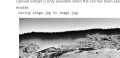

In [4]:
a = int(input('Enter lower input intensity: '))
b = int(input('Enter upper input intensity: '))
c = int(input('Enter lower output intensity: '))
d = int(input('Enter upper output intensity: '))
x = gray.astype(np.float64)
result = np.zeros_like(x)
mask1 = x <= a
mask2 = (x > a) & (x <= b)
mask3 = x > b
result[mask1] = (c / a) * x[mask1]
result[mask2] = c + ((d - c) / (b - a)) * (x[mask2] - a)
result[mask3] = d + ((255 - d) / (255 - b)) * (x[mask3] - b)
result = np.clip(result, 0, 255).astype(np.uint8)
cv2.imwrite('outputs/assignment4/contrast_stretching.jpg', result)
